# Week 9 Lecture Notes: Ensemble Methods: Bagging and Boosting

## Contents

- [Scope for Week 9](#scope-for-week-9)
- [Learning goals for this notebook](#learning-goals-for-this-notebook)
- [Chapter 7 summary](#chapter-7-summary)
  - [Ensemble methods](#ensemble-methods)
  - [Bootstrap and bagging](#bootstrap-and-bagging)
  - [Why bagging reduces variance](#why-bagging-reduces-variance)
  - [Out-of-bag error estimation](#out-of-bag-error-estimation)
  - [Random forests](#random-forests)
  - [Boosting](#boosting)
  - [AdaBoost](#adaboost)
  - [Gradient boosting](#gradient-boosting)
  - [Objective, optimisation, failure modes](#objective-optimisation-failure-modes)
- [Exam-oriented takeaways](#exam-oriented-takeaways)
- [Past exam questions (2023-2025)](#past-exam-questions-2023-2025)
- [Toy example 1: bootstrap samples and out-of-bag points](#toy-example-1-bootstrap-samples-and-out-of-bag-points)
- [Toy example 2: why correlation limits bagging](#toy-example-2-why-correlation-limits-bagging)
- [Toy example 3: AdaBoost weight updates by hand](#toy-example-3-adaboost-weight-updates-by-hand)
- [Week 9 wrap-up](#week-9-wrap-up)
- [Sources used](#sources-used)

## Scope for Week 9

- Topic: ensemble methods, especially bagging and boosting.
- Important concepts: bootstrapping, averaging, base-model correlation, bias-variance decomposition, out-of-bag error, sequential reweighting, and additive models.
- Algorithms and methods: bagging, random forests, boosting, AdaBoost, and gradient boosting.
- Reading: [Lindholm (2022), Chapter 7](../../references/main-text-book-machine-learning-lindholm-2022.pdf). The [Course Summary Table](../../references/CourseSummaryTable_v1_26.pdf) schedules Week 9 as "Ensemble Methods: Bagging and Boosting".
- Prac alignment: Week 9 is listed as a catchup/review prac with demos; the ensemble methods prac is scheduled for Week 10.
- Supporting-source note: the local [MATLAB notes](../../references/lecture_notes_matlab_2026_v2.pdf) are used only as supporting clarification. The structure here follows the course schedule, Lindholm Chapter 7, and the indexed exam materials.

## Learning goals for this notebook

1. Explain bagging, random forests, and boosting in bias-variance language.
2. Compute and interpret the variance reduction from averaging correlated base models.
3. Distinguish bagging from boosting in exam language: parallel vs sequential training, variance reduction vs bias reduction, equal averaging vs weighted/additive voting.

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

SEED = 4702
random.seed(SEED)
np.random.seed(SEED)
plt.rcParams["figure.dpi"] = 120

print(f"Seed set to {SEED}")

Seed set to 4702


## Chapter 7 summary

### Ensemble methods

An **ensemble method** builds several base models and combines their predictions into one final prediction.

Why it matters:

- one unstable model can have high variance;
- an average or vote over several differently trained models can be more stable;
- a sequential ensemble can build a complex predictor from simple base models.

The base models might be decision trees, stumps, neural networks, or another supervised learner. The important point is that the final model is not a single fitted base model; it is a combination rule over many fitted base models.

For a regression ensemble, a common prediction rule is

$$
\hat{y}_{\mathrm{ens}}(x_\star)
= \frac{1}{B}\sum_{b=1}^{B} \hat{y}^{(b)}(x_\star),
$$

where $B$ is the number of base models. For classification, we may average class-probability vectors or use a majority vote. Averaging probabilities is usually the more informative operation because it keeps uncertainty information before the final class decision.

### Bootstrap and bagging

**Bootstrapping** creates a new dataset of size $n$ by sampling $n$ times from the original training set **with replacement**.

If the original dataset is

$$
T = \{(x_i, y_i)\}_{i=1}^{n},
$$

then a bootstrap dataset $\widetilde{T}^{(b)}$ contains repeated copies of some training points and omits others. This matters because it gives each base model a slightly different version of the same training problem without collecting new data.

**Bagging**, short for bootstrap aggregating, is:

1. draw $B$ bootstrap datasets $\widetilde{T}^{(1)}, \ldots, \widetilde{T}^{(B)}$;
2. train one base model on each bootstrap dataset;
3. average the predictions for regression or class probabilities, or vote for hard classification.

For regression, Lindholm writes the bagged prediction as

$$
\hat{y}_{\mathrm{bag}}(x_\star)
= \frac{1}{B}\sum_{b=1}^{B}\widetilde{y}^{(b)}(x_\star).
\qquad (7.1)
$$

For classification with probability outputs,

$$
g_{\mathrm{bag}}(x_\star)
= \frac{1}{B}\sum_{b=1}^{B}\widetilde{g}^{(b)}(x_\star).
\qquad (7.1)
$$

Minimal definition:

- **bagging** is an ensemble method that trains base models on bootstrap samples and averages their predictions to reduce variance.

Best base models for bagging:

- flexible, low-bias, high-variance learners;
- decision trees grown deep are the standard example;
- bagging a high-bias model usually does not fix the bias much.

### Why bagging reduces variance

The core mathematical fact is that averaging reduces variance when the quantities being averaged are not perfectly correlated.

Let $z_1,\ldots,z_B$ be identically distributed random variables with mean $\mu$, variance $\sigma^2$, and average pairwise correlation $\rho$. Lindholm gives

$$
\mathbb{E}\left[\frac{1}{B}\sum_{b=1}^{B} z_b\right] = \mu,
\qquad (7.2a)
$$

and

$$
\mathrm{Var}\left[\frac{1}{B}\sum_{b=1}^{B} z_b\right]
= \left(\frac{1-\rho}{B} + \rho\right)\sigma^2.
\qquad (7.2b)
$$

Interpretation:

- the average prediction has the same mean, so the main bias does not change much;
- the variance decreases as $B$ increases;
- the limiting variance is controlled by $\rho\sigma^2$;
- if base models are highly correlated, bagging has less room to help.

Important exam point:

- increasing $B$ in bagging does **not** make the ensemble more flexible in the same way that increasing polynomial degree or tree depth does;
- test error should decrease or plateau as $B$ grows, not eventually rise because $B$ is too large;
- overfitting can still occur because each base model overfits, but it is not caused by having too many bagged members.

This is a common source of wrong answers: "too many bagged trees causes overfitting" is not the Chapter 7 message. The computational cost increases with $B$, but the statistical trend is variance reduction toward a plateau.

### Out-of-bag error estimation

In a bootstrap sample of size $n$, any particular training point has probability

$$
\left(1-\frac{1}{n}\right)^n \approx e^{-1} \approx 0.368
$$

of being left out. Therefore, each bootstrap dataset includes about $63.2\%$ of the distinct original training points and leaves about $36.8\%$ out.

For a fixed training point $(x_i,y_i)$:

- some base models were trained on bootstrap samples that did not contain $(x_i,y_i)$;
- those base models are **out-of-bag** for point $i$;
- they can be used to predict $x_i$ as if it were a held-out point.

The **out-of-bag error** averages these held-out-style errors over all training points. It is useful because it gives a generalisation-error estimate almost for free after fitting the bagged ensemble or random forest.

Failure mode:

- OOB error is still an estimate, not a replacement for a final untouched test set when a final test protocol is required.

### Random forests

A **random forest** is bagging applied to decision trees, with extra randomness during tree construction.

The extra step:

- when splitting a node, choose a random subset of $q \le p$ input variables;
- search for the best split only among those $q$ variables;
- draw a fresh random subset at each split and for each tree.

This reduces correlation between trees. In the variance formula above, the goal is to reduce $\rho$ enough that the ensemble variance drops, even if the individual trees become noisier.

Key tradeoff:

- using fewer candidate variables can make each tree worse on its own;
- but it can make the ensemble better because the trees become less similar.

Special cases and rules of thumb:

- $q=p$ recovers ordinary bagged trees;
- for classification, Lindholm gives $q=\sqrt{p}$ as a rule of thumb;
- for regression, Lindholm gives $q=p/3$ as a rule of thumb;
- better practice: tune $q$ with OOB error or cross-validation.

Minimal definition:

- a **random forest** is an ensemble of bootstrapped decision trees where each split considers only a random subset of features.

Exam wording to remember:

- random forests improve over simple bagged tree ensembles mainly by reducing correlation between base models.

### Boosting

**Boosting** is an ensemble method that trains base models sequentially, so each new model focuses on mistakes made by the current ensemble.

Contrast with bagging:

- bagging trains base models independently and can be parallelised;
- boosting trains base models sequentially and is harder to parallelise;
- bagging mainly reduces variance;
- boosting mainly reduces bias;
- bagging often works well with high-variance base learners;
- boosting often works well with weak high-bias base learners such as decision stumps.

The basic idea is that a weak learner can still be useful if it is slightly better than random. Combining many weak learners can produce a strong nonlinear predictor.

Failure mode:

- unlike bagging, boosting can overfit as $B$ grows because each new member is added to improve the current fitted function;
- boosting can also be sensitive to noisy labels or outliers, especially AdaBoost with exponential loss.

### AdaBoost

AdaBoost is the classic boosting method for binary classification with labels $y_i \in \{-1,+1\}$.

It builds a weighted vote of weak classifiers:

$$
\hat{y}_{\mathrm{boost}}^{(B)}(x)
= \mathrm{sign}\left\{
\sum_{b=1}^{B}\alpha^{(b)}\hat{y}^{(b)}(x)
\right\}.
\qquad (7.4)
$$

Here:

- $\hat{y}^{(b)}(x)$ is the $b$th weak classifier;
- $\alpha^{(b)}$ is its vote weight or confidence;
- larger $\alpha^{(b)}$ means the model trusts that weak classifier more.

At iteration $b$, AdaBoost:

1. trains a weak classifier on weighted data;
2. computes its weighted training error

$$
E_{\mathrm{train}}^{(b)}
= \sum_{i=1}^{n} w_i^{(b)} I\{y_i \ne \hat{y}^{(b)}(x_i)\},
\qquad (7.12)
$$

assuming the weights are normalised to sum to one;

3. sets the classifier confidence

$$
\alpha^{(b)}
= \frac{1}{2}\log\left(
\frac{1-E_{\mathrm{train}}^{(b)}}{E_{\mathrm{train}}^{(b)}}
\right);
\qquad (7.13)
$$

4. increases the weights of misclassified points and decreases the weights of correctly classified points:

$$
w_i^{(b+1)}
\propto
w_i^{(b)}
\exp\{-\alpha^{(b)}y_i\hat{y}^{(b)}(x_i)\}.
$$

The sign inside the exponential is the key:

- if $y_i\hat{y}^{(b)}(x_i)=+1$, the point was correct and its weight shrinks;
- if $y_i\hat{y}^{(b)}(x_i)=-1$, the point was wrong and its weight grows.

AdaBoost is derived from greedily minimising exponential loss. That derivation explains why the base learner is trained with weighted misclassification loss and why the $\alpha^{(b)}$ formula appears.

Important detail:

- $\alpha^{(b)}>0$ only when $E_{\mathrm{train}}^{(b)}<0.5$;
- if a weak classifier is worse than random guessing, its predictions can be flipped.

### Gradient boosting

Gradient boosting generalises the boosting idea as greedy training of an additive model:

$$
f^{(B)}(x) = \sum_{b=1}^{B}\alpha^{(b)}f^{(b)}(x).
\qquad (7.14)
$$

The goal is to minimise an empirical loss

$$
J(f(X)) = \frac{1}{n}\sum_{i=1}^{n} L(y_i, f(x_i)).
\qquad (7.15)
$$

Instead of requiring a closed-form update like AdaBoost, gradient boosting:

1. computes the negative gradient of the loss with respect to the current predictions on the training data;
2. fits the next base model to those negative-gradient targets;
3. chooses a step size, often by line search;
4. adds the new base model to the ensemble, often with a shrinkage multiplier $\gamma<1$.

The practical intuition:

- each new model is trained to move the current predictions in a direction that lowers the loss;
- for squared-error regression, the negative-gradient targets are residual-like quantities;
- for classification, the fitted intermediate targets can be real-valued even though the labels are classes.

Why this matters:

- gradient boosting can use losses other than exponential loss;
- logistic loss is a common safer choice for classification because it is smoother and less dominated by very large negative margins than exponential loss;
- tree-based gradient boosting is a major practical method family, including implementations such as XGBoost and LightGBM.

### Objective, optimisation, failure modes

Objective:

- Bagging/random forests: keep a low-bias base learner but reduce prediction variance by averaging.
- Boosting: reduce bias by building a strong additive predictor from many weak or shallow base learners.

Optimisation:

- Bagging: fit each base model independently on a bootstrap sample; combine by averaging or voting.
- Random forests: same as bagging, but randomise the feature candidates at each tree split.
- AdaBoost: greedily add weighted weak classifiers by minimising exponential loss.
- Gradient boosting: greedily add base functions in a negative-gradient direction for a chosen loss.

Failure modes:

- Bagging with highly correlated base models gives limited variance reduction.
- Bagging does not fix a badly biased base model.
- Random forests can underperform with too much feature subsampling or too few trees.
- Boosting can overfit with too many iterations or too flexible base learners.
- AdaBoost can focus heavily on noisy labels or outliers because exponential loss strongly penalises large negative margins.

## Exam-oriented takeaways

High-priority facts from the 2023-2025 exam index:

1. Bagging uses bootstrap samples and can train base models in parallel.
2. Bagging reduces variance; it does not mainly reduce bias.
3. Increasing $B$ in bagging should reduce or plateau error, not create a new overfitting effect by itself.
4. OOB error works because each bootstrap sample omits about one third of the distinct training points.
5. Random forests improve simple bagged trees by reducing correlation between trees through random feature subsets.
6. Boosting trains base models sequentially, with later models focusing on earlier errors.
7. Boosting mainly reduces bias and can overfit as $B$ grows.
8. AdaBoost uses weighted misclassification for the weak learner and a weighted majority vote for prediction.
9. Gradient boosting views boosting as greedy optimisation of an additive model under a chosen loss.

Fast exam checklist:

- Can I explain bagging in one sentence using "bootstrap" and "variance"?
- Can I derive or interpret $\left((1-\rho)/B+\rho\right)\sigma^2$?
- Can I say why random forests reduce correlation compared with bagged trees?
- Can I state one similarity and one difference between bagging and boosting?
- Can I explain why bootstrapping helps in bias-variance terms?

## Past exam questions (2023-2025)

Note: these are copied from the exam text extraction file: [COMP4702_exams_2023_2025.md](../../references/COMP4702_exams_2023_2025.md), using the week index in [exam_questions_2023_2025_by_week.csv](../../references/exam_questions_2023_2025_by_week.csv).

### 2023 exam

- Question 7. Regarding bagging, which of the following statements is incorrect? ([2023 exam PDF](../../references/2023_COMP4702_exam.pdf), Part A)
  - (a) Bagging allows multiple models to be trained in parallel.
  - (b) Bagging uses bootstrap sampling to create multiple training sets.
  - (c) Bagging tends to increase bias when the size of the ensemble grows too large.
  - (d) Bagging tends to reduce the model error variance compared to a single base model.

### 2024 exam

- Question 8. An important difference between bagging and boosting is that: ([2024 exam PDF](../../references/2024_COMP4702_exam.pdf), Part A)
  - (a) Bagging is suitable for regression problems, while boosting is suitable for classification problems.
  - (b) Bagging can build a heterogeneous ensemble of models, while for boosting the ensemble must be homogeneous.
  - (c) Boosting trains an ensemble of models sequentially, while bagging can be implemented in parallel.
  - (d) Boosting allows for ensembles of any size, while in bagging the number of base models must be less than the number of data points.
- Question 4(a) (Part B): ([2024 exam PDF](../../references/2024_COMP4702_exam.pdf), Part B)
  - Compare the ensemble methods of bagging and boosting. Write a few sentences, giving one similarity and one difference between the two techniques. (5 marks)
- Question 4(b) (Part B): ([2024 exam PDF](../../references/2024_COMP4702_exam.pdf), Part B)
  - Figure 4 is from the course textbook and shows an estimate of the generalisation error for a regression problem, as a function of the number of base models (B) in a bagged ensemble. Explain what the graph tells us and why this trend is to be expected, by referring to the bias-variance decomposition of error. (5 marks)

### 2025 exam

- Question 7. Random forests aim to improve performance over simple bagged ensembles by: ([2025 exam PDF](../../references/2025_COMP4702_exam.pdf), Part A)
  - (a) Allowing the decision tree base models to grow to a larger depth.
  - (b) Repeatedly reshuffling the data prior to training each base model.
  - (c) Implementing aggressive pruning within the base models, so that the forest can be seen for the trees.
  - (d) Reducing the correlation between the base models in the ensemble.
- Question 9 (Part B): ([2025 exam PDF](../../references/2025_COMP4702_exam.pdf), Part B)
  - Many ensemble methods in machine learning use the idea of bootstrapping. Explain briefly why this is an effective way of reducing model error in terms of the bias-variance decomposition. (4 marks)

### Answer checkpoints

- 2023 Part A Q7: (c).
- 2024 Part A Q8: (c).
- 2025 Part A Q7: (d).
- For 2024 Part B Q4(b), the expected trend is: error decreases quickly at first as $B$ increases, then plateaus because the reducible variance term shrinks while the correlation-limited term remains.
- For 2025 Part B Q9, the key phrase is: bootstrapping creates varied base models whose average keeps bias roughly similar while reducing variance, especially when base-model predictions are not perfectly correlated.

## Toy example 1: bootstrap samples and out-of-bag points

This cell checks the bootstrap inclusion rate. For large $n$, each bootstrap sample should contain about $63.2\%$ of the distinct training points and leave about $36.8\%$ out.

In [2]:
rng = np.random.default_rng(SEED)

n = 1000
B = 500
samples = rng.integers(0, n, size=(B, n))

included = np.zeros((B, n), dtype=bool)
for b in range(B):
    included[b, samples[b]] = True

distinct_inclusion_rate = included.mean(axis=1)
oob_rate = 1.0 - distinct_inclusion_rate

theory_oob = (1.0 - 1.0 / n) ** n
print(f"Average distinct inclusion rate: {distinct_inclusion_rate.mean():.3f}")
print(f"Average out-of-bag rate:          {oob_rate.mean():.3f}")
print(f"Theoretical OOB approximation:    {theory_oob:.3f}")

Average distinct inclusion rate: 0.631
Average out-of-bag rate:          0.369
Theoretical OOB approximation:    0.368


Interpretation:

- sampling with replacement is essential;
- without replacement, each resample of size $n$ would just contain all training points once, so the base models would be much less perturbed;
- the omitted points are what make OOB error possible.

## Toy example 2: why correlation limits bagging

This cell evaluates Lindholm equation (7.2b). The main lesson is that increasing $B$ helps most when base-model predictions are weakly correlated.

rho=0.0 -> B=1: 1.000, B=2: 0.500, B=5: 0.200, B=10: 0.100, B=25: 0.040, B=50: 0.020, B=100: 0.010
rho=0.2 -> B=1: 1.000, B=2: 0.600, B=5: 0.360, B=10: 0.280, B=25: 0.232, B=50: 0.216, B=100: 0.208
rho=0.8 -> B=1: 1.000, B=2: 0.900, B=5: 0.840, B=10: 0.820, B=25: 0.808, B=50: 0.804, B=100: 0.802


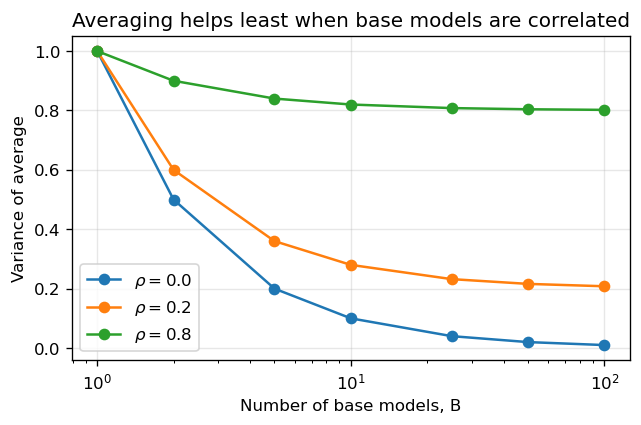

In [3]:
def variance_of_average(B, rho, sigma2=1.0):
    return ((1.0 - rho) / B + rho) * sigma2


B_values = np.array([1, 2, 5, 10, 25, 50, 100])
rho_values = [0.0, 0.2, 0.8]

for rho in rho_values:
    values = [variance_of_average(B, rho) for B in B_values]
    formatted = ", ".join(f"B={B}: {v:.3f}" for B, v in zip(B_values, values))
    print(f"rho={rho:.1f} -> {formatted}")

plt.figure(figsize=(6, 3.5))
for rho in rho_values:
    y_vals = [variance_of_average(B, rho) for B in B_values]
    plt.plot(B_values, y_vals, marker="o", label=fr"$\rho={rho}$")

plt.xscale("log")
plt.xlabel("Number of base models, B")
plt.ylabel("Variance of average")
plt.title("Averaging helps least when base models are correlated")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Exam interpretation:

- $\rho=0$: variance drops approximately like $1/B$;
- $\rho=0.8$: the ensemble variance quickly plateaus near $0.8\sigma^2$;
- random forests try to reduce $\rho$ compared with ordinary bagged trees.

## Toy example 3: AdaBoost weight updates by hand

This is a minimal 1D AdaBoost implementation using decision stumps. The point is not to build a production classifier; it is to see the weighted-error, $\alpha$, and weight-update mechanics.

In [4]:
x = np.array([-2.0, -1.4, -0.9, -0.2, 0.3, 0.8, 1.2, 1.8])
y = np.array([-1, -1, 1, -1, 1, 1, -1, 1])


def best_weighted_stump(x, y, w):
    thresholds = np.r_[x.min() - 1.0, (x[:-1] + x[1:]) / 2.0, x.max() + 1.0]
    best = None

    for threshold in thresholds:
        base_pred = np.where(x <= threshold, -1, 1)
        for polarity in [1, -1]:
            pred = polarity * base_pred
            err = np.sum(w[pred != y])
            if best is None or err < best["err"]:
                best = {
                    "threshold": threshold,
                    "polarity": polarity,
                    "pred": pred,
                    "err": err,
                }
    return best


w = np.ones_like(y, dtype=float) / len(y)
ensemble_score = np.zeros_like(y, dtype=float)
history = []

for b in range(1, 4):
    stump = best_weighted_stump(x, y, w)
    err = np.clip(stump["err"], 1e-12, 1.0 - 1e-12)
    alpha = 0.5 * np.log((1.0 - err) / err)

    pred = stump["pred"]
    ensemble_score += alpha * pred
    ensemble_pred = np.sign(ensemble_score)
    train_acc = np.mean(ensemble_pred == y)

    history.append(
        {
            "b": b,
            "threshold": stump["threshold"],
            "polarity": stump["polarity"],
            "weighted_error": stump["err"],
            "alpha": alpha,
            "train_accuracy_so_far": train_acc,
        }
    )

    w = w * np.exp(-alpha * y * pred)
    w = w / w.sum()

for row in history:
    print(
        "b={b}, threshold={threshold:.2f}, polarity={polarity:+d}, "
        "weighted_error={weighted_error:.3f}, alpha={alpha:.3f}, "
        "train_accuracy_so_far={train_accuracy_so_far:.3f}".format(**row)
    )

print("Final weights:", np.round(w, 3))

b=1, threshold=-1.15, polarity=+1, weighted_error=0.250, alpha=0.549, train_accuracy_so_far=0.750
b=2, threshold=1.50, polarity=+1, weighted_error=0.250, alpha=0.549, train_accuracy_so_far=0.375
b=3, threshold=-1.15, polarity=+1, weighted_error=0.333, alpha=0.347, train_accuracy_so_far=0.750
Final weights: [0.042 0.042 0.125 0.25  0.125 0.125 0.25  0.042]


What to notice:

- the first stump is only a weak classifier, not a perfect classifier;
- misclassified examples receive larger relative weight in the next round;
- later stumps are chosen under a different weighted problem;
- the final classifier is a weighted vote, not a simple unweighted majority vote.

## Week 9 wrap-up

Bagging, random forests, and boosting are all ensemble methods, but they solve different problems.

- Bagging: reduce variance by averaging bootstrap-trained base models.
- Random forests: reduce tree correlation by adding random feature subsampling at splits.
- Boosting: reduce bias by sequentially adding base models that improve the current ensemble.
- AdaBoost: boosting with exponential loss, weighted examples, and weighted votes.
- Gradient boosting: boosting as greedy optimisation of a general additive model.

The exam pattern is consistent: be able to explain the mechanism, not just name the method. The highest-yield explanations use the bias-variance decomposition and the correlation term in the variance-of-an-average formula.

## Sources used

1. [Course Summary Table, Semester 1 2026](../../references/CourseSummaryTable_v1_26.pdf): Week 9 topic, concepts, algorithms, reading, and prac alignment.
2. [Lindholm et al. (2022), Chapter 7](../../references/main-text-book-machine-learning-lindholm-2022.pdf): primary reading for bagging, random forests, AdaBoost, and gradient boosting.
3. [MATLAB lecture notes 2026 v2](../../references/lecture_notes_matlab_2026_v2.pdf): supporting clarification for Week 9 ensemble-method framing.
4. [Exam question index by week](../../references/exam_questions_2023_2025_by_week.csv) and [extracted exam text](../../references/COMP4702_exams_2023_2025.md): past exam question selection and wording.